In [1]:
!pip install osmnx geopandas shapely libpysal esda

In [2]:


pip install geopandas


Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install osmnx

Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath(".."))

# Main

<Axes: >

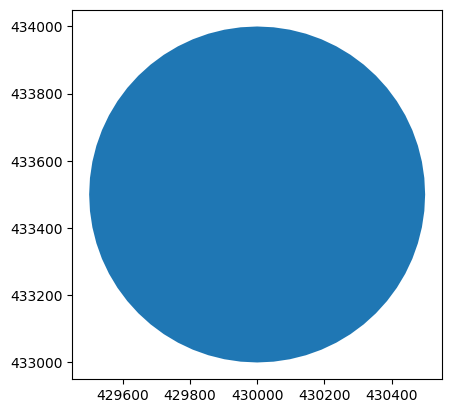

In [14]:
import geopandas as gpd
from shapely.geometry import Point

# centre of densest accident cluster (from scatterplot)
center_easting = 430000
center_northing = 433500

center_point = Point(center_easting, center_northing)

# create 500m buffer (~1 km² area)
buffer_area = center_point.buffer(500)

study_area = gpd.GeoDataFrame(geometry=[buffer_area], crs="EPSG:27700")

study_area.plot()

In [15]:
accidents_area = gdf[gdf.within(buffer_area)]

print("Accidents in 1km² study area:", len(accidents_area))

Accidents in 1km² study area: 67


In [16]:
study_area_wgs = study_area.to_crs(epsg=4326)

polygon = study_area_wgs.geometry.iloc[0]

In [17]:
center_lat = 53.7997
center_lon = -1.5492

In [18]:
import osmnx as ox

G = ox.graph_from_point(
    (center_lat, center_lon),
    dist=1000,        # 1000 meters radius
    network_type="drive"
)

print("Nodes:", len(G.nodes()))
print("Edges:", len(G.edges()))

Nodes: 646
Edges: 1231


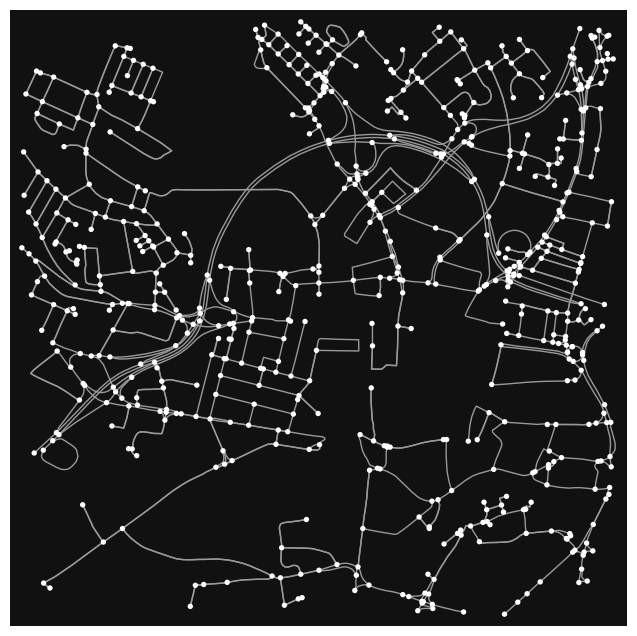

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [19]:
ox.plot_graph(G)

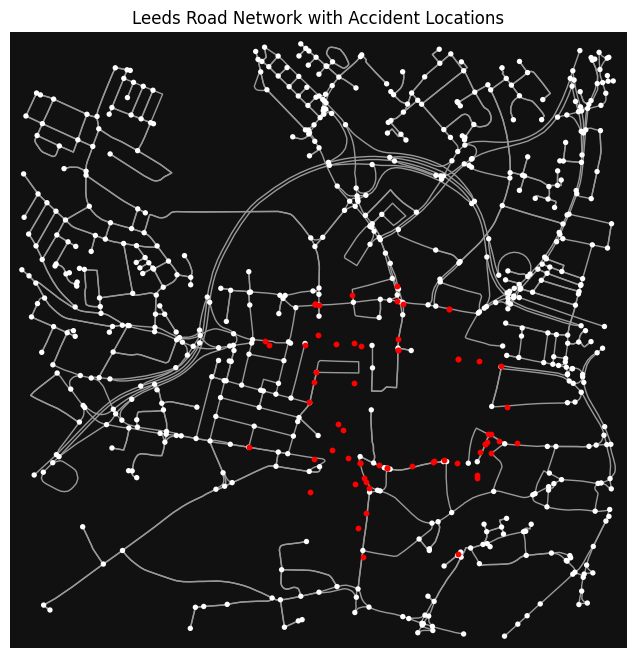

In [20]:
fig, ax = ox.plot_graph(G, show=False, close=False)

accidents_area.to_crs(epsg=4326).plot(
    ax=ax,
    color='red',
    markersize=10
)

plt.title("Leeds Road Network with Accident Locations")
plt.show()

## Task A : Basic Network Statistics

In [21]:
import numpy as np

num_nodes = len(G.nodes())
num_edges = len(G.edges())

print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)

Number of nodes: 646
Number of edges: 1231


### Average Street Length

In [22]:
edge_lengths = [data['length'] for u, v, data in G.edges(data=True)]

avg_street_length = np.mean(edge_lengths)

print("Average street length (m):", avg_street_length)

Average street length (m): 73.29148302154435


### Node Density

In [23]:
area_km2 = 3.14

node_density = num_nodes / area_km2

print("Node density (nodes per km²):", node_density)

Node density (nodes per km²): 205.7324840764331


### Edge Density

In [24]:
edge_density = num_edges / area_km2

print("Edge density (edges per km²):", edge_density)

Edge density (edges per km²): 392.0382165605095


### Spatial Diameter

This measures the longest shortest path in the network.

In [25]:
# convert to undirected graph
G_u = G.to_undirected()

# compute approximate diameter (faster for large graphs)
diameter = nx.approximation.diameter(G_u)

print("Network diameter:", diameter)

Network diameter: 53


### Circuitry

Circuitry measures how indirect routes are.

In [26]:
# project network to meters
G_proj = ox.project_graph(G)

In [27]:
import random
import numpy as np

nodes = list(G_proj.nodes())

ratios = []

for i in range(50):

    n1, n2 = random.sample(nodes, 2)

    try:
        network_dist = nx.shortest_path_length(G_proj, n1, n2, weight="length")

        x1, y1 = G_proj.nodes[n1]['x'], G_proj.nodes[n1]['y']
        x2, y2 = G_proj.nodes[n2]['x'], G_proj.nodes[n2]['y']

        euclidean = ((x1-x2)**2 + (y1-y2)**2)**0.5

        ratios.append(network_dist / euclidean)

    except:
        pass

circuitry = np.mean(ratios)

print("Average circuitry:", circuitry)

Average circuitry: 1.9590248694319365


### Planarity Test

Road networks are almost planar but not perfectly.

In [28]:
is_planar, embedding = nx.check_planarity(G_u)

print("Is network planar?", is_planar)

Is network planar? False


# Task B

## Uploading more data for Further analysis

In [29]:
df2015 = pd.read_csv("../data/raw/2015.csv", encoding="latin1")
df2016 = pd.read_csv("../data/raw/2016.csv", encoding="latin1")
df2017 = pd.read_csv("../data/raw/2017.csv", encoding="latin1")
df2018 = pd.read_csv("../data/raw/2018.csv", encoding="latin1")
df2019 = pd.read_csv("../data/raw/2019.csv", encoding="latin1")

df_all = pd.concat([df2015, df2016, df2017, df2018, df2019])

In [30]:
print(df_all.shape)

(11505, 34)


### Define Leeds City Centre

In [43]:
center_lat = 53.8008
center_lon = -1.5491

### Create 1km² Study Area

<Axes: >

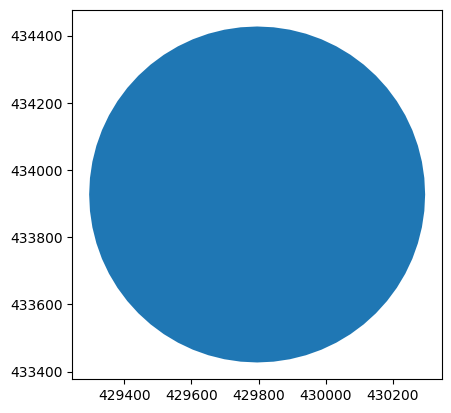

In [44]:
import geopandas as gpd
from shapely.geometry import Point

center_point = gpd.GeoDataFrame(
    geometry=[Point(center_lon, center_lat)],
    crs="EPSG:4326"
)

center_point = center_point.to_crs(epsg=27700)

study_area = center_point.buffer(500)

study_area = gpd.GeoDataFrame(geometry=study_area, crs="EPSG:27700")

study_area.plot()

### Filter Accidents

In [45]:
gdf_all = gdf_all.to_crs(epsg=27700)

accidents_area = gdf_all[gdf_all.within(study_area.geometry.iloc[0])]

print("Accidents in study area:", len(accidents_area))

Accidents in study area: 113


### Create Grid

In [46]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Polygon

minx, miny, maxx, maxy = study_area.total_bounds

cell_size = 100

grid_cells = []

for x in np.arange(minx, maxx, cell_size):
    for y in np.arange(miny, maxy, cell_size):

        grid_cells.append(
            Polygon([
                (x, y),
                (x + cell_size, y),
                (x + cell_size, y + cell_size),
                (x, y + cell_size)
            ])
        )

grid = gpd.GeoDataFrame({"geometry": grid_cells}, crs="EPSG:27700")

print("Grid cells created:", len(grid))

Grid cells created: 100


### Intersect Grid With Study Area

In [47]:
grid = gpd.overlay(grid, study_area, how="intersection")

print("Cells inside study area:", len(grid))

Cells inside study area: 88


### Count Accidents Per Cell

In [48]:
join = gpd.sjoin(grid, accidents_area, how="left", predicate="contains")

counts = join.groupby(join.index).size()

grid["accident_count"] = counts

grid["accident_count"] = grid["accident_count"].fillna(0)

### Plot Accident Density

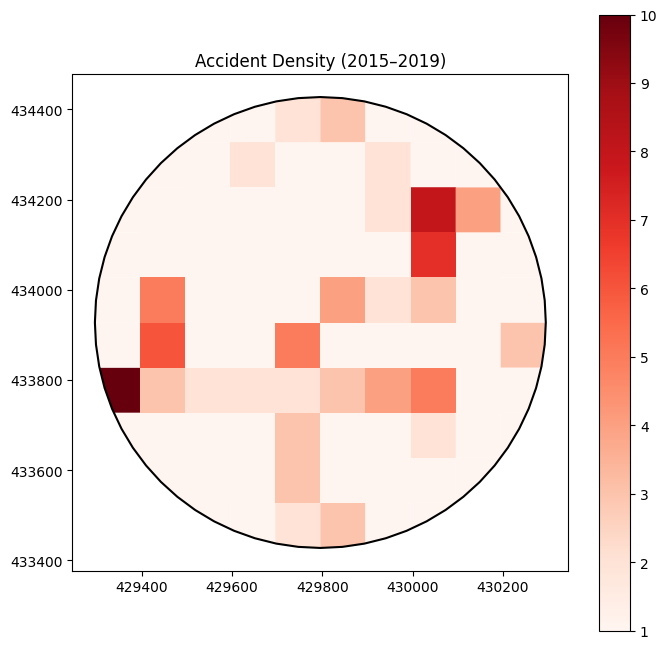

In [49]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,8))

grid.plot(
    column="accident_count",
    cmap="Reds",
    legend=True,
    ax=ax
)

study_area.boundary.plot(ax=ax, color="black")

plt.title("Accident Density (2015–2019)")

plt.show()

### Moran's I

In [50]:
from libpysal.weights import Queen
from esda.moran import Moran

w = Queen.from_dataframe(grid)

moran = Moran(grid["accident_count"], w)

print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.06979114375544927
p-value: 0.068


/var/folders/q4/0120p0vj49g0dbygwm51p8xc0000gn/T/ipykernel_42580/3469004061.py:4: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(grid)


### Extract Intersections from Road Network

In [51]:
nodes, edges = ox.graph_to_gdfs(G)

# intersections are nodes with degree >=3
intersections = nodes[nodes["street_count"] >= 3]

print("Number of intersections:", len(intersections))

Number of intersections: 513


### Convert CRS to Match

In [52]:
intersections = intersections.to_crs(epsg=27700)

### Calculate Distance to Nearest Intersection

In [ ]:
import spaghetti
import warnings
warnings.filterwarnings('ignore')

# Create spaghetti spatial network from road edges
net = spaghetti.Network(in_data=edges)

# Snap the accident points to the network
net.snapobservations(accidents_area, 'accidents')
patt = net.pointpatterns['accidents']

dist_to_intersection = []
for i in range(len(accidents_area)):
    # Euclidean distance from the point to the road segment
    snap_dist = patt.dist_snapped[i]
    
    # Shortest network distance along the road segment to its intersection (vertex)
    net_dist = min(patt.dist_to_vertex[i].values())
    
    # Total distance is the sum of snapping distance and network distance
    dist_to_intersection.append(snap_dist + net_dist)

accidents_area['dist_to_intersection'] = dist_to_intersection
accidents_area['dist_to_intersection'].describe()

### Visualise Distances

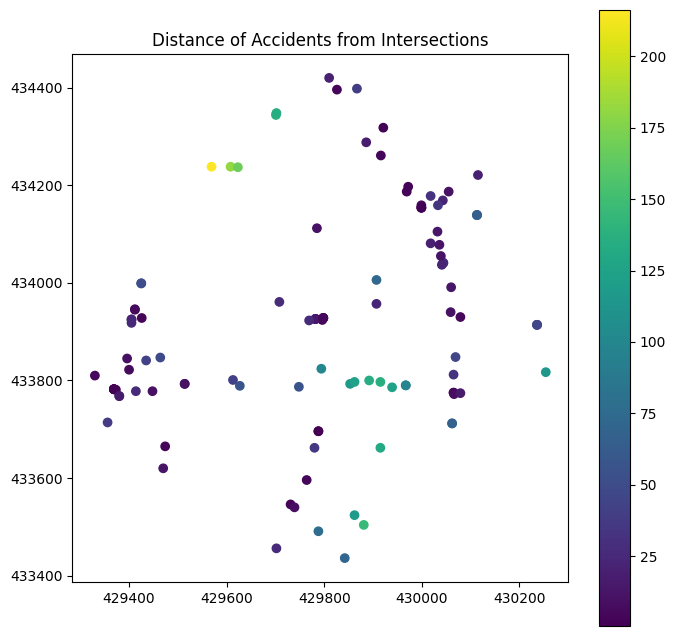

In [54]:
accidents_area.plot(
    column="dist_to_intersection",
    cmap="viridis",
    legend=True,
    figsize=(8,8)
)

plt.title("Distance of Accidents from Intersections")

plt.show()

# Task C

### Get Leeds Boundary

<Axes: >

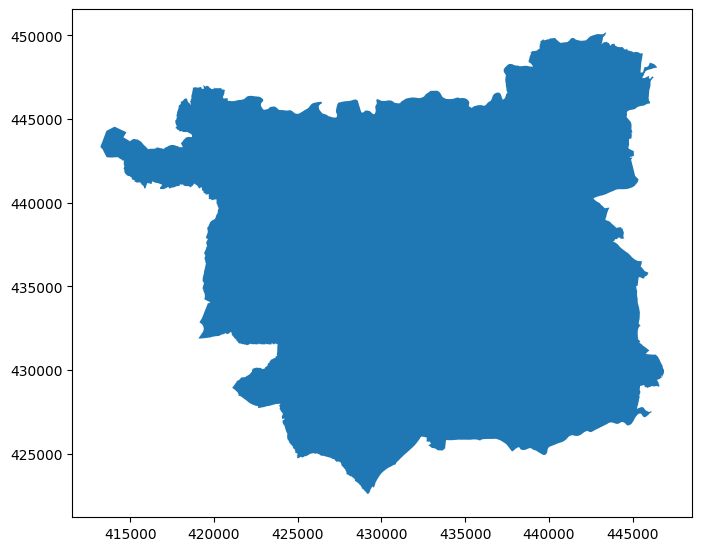

In [56]:
import osmnx as ox
import geopandas as gpd

leeds = ox.geocode_to_gdf("Leeds, UK")

leeds = leeds.to_crs(epsg=27700)

leeds.plot(figsize=(8,8))

Choose 4 Marathon Start Points

<Axes: >

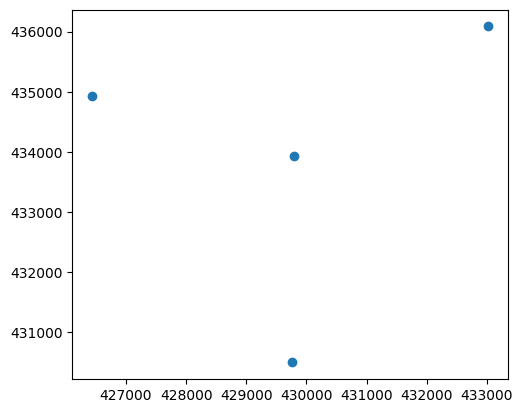

In [57]:
import geopandas as gpd
from shapely.geometry import Point

points = gpd.GeoDataFrame(
    geometry=[
        Point(-1.5491,53.8008),  # city centre
        Point(-1.6000,53.8100),  # west Leeds
        Point(-1.5000,53.8200),  # east Leeds
        Point(-1.5500,53.7700)   # south Leeds
    ],
    crs="EPSG:4326"
)

points = points.to_crs(epsg=27700)

points.plot()

Generate Voronoi Diagram

In [58]:
from shapely.ops import voronoi_diagram

multi = points.unary_union

vor = voronoi_diagram(multi)

/var/folders/q4/0120p0vj49g0dbygwm51p8xc0000gn/T/ipykernel_42580/698311296.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  multi = points.unary_union


Convert Voronoi to GeoDataFrame

In [59]:
import geopandas as gpd
cells = list(vor.geoms)

voronoi_gdf = gpd.GeoDataFrame(geometry=cells, crs=points.crs)

Clip to Leeds Boundary

In [60]:
voronoi_clipped = gpd.overlay(voronoi_gdf, leeds, how="intersection")

Visualise Marathon Zones

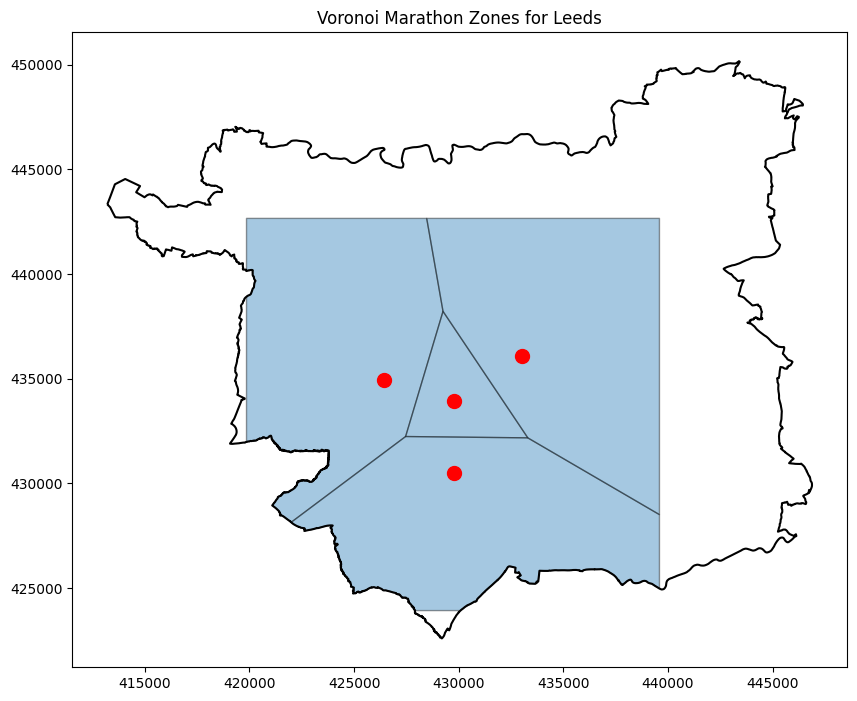

In [62]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

voronoi_clipped.plot(
    ax=ax,
    edgecolor="black",
    alpha=0.4
)

leeds.boundary.plot(ax=ax, color="black")

points.plot(ax=ax, color="red", markersize=100)

plt.title("Voronoi Marathon Zones for Leeds")

plt.show()

Calculate Area of Each Marathon Zone

In [63]:
voronoi_clipped["area_km2"] = voronoi_clipped.geometry.area / 1e6

voronoi_clipped[["area_km2"]]

,area_km2
0,100.725670
1,17.527871
2,96.401487
3,109.462094


Label Each Marathon Zone

In [65]:
voronoi_clipped["marathon_id"] = range(1,5)

Final Visualisation

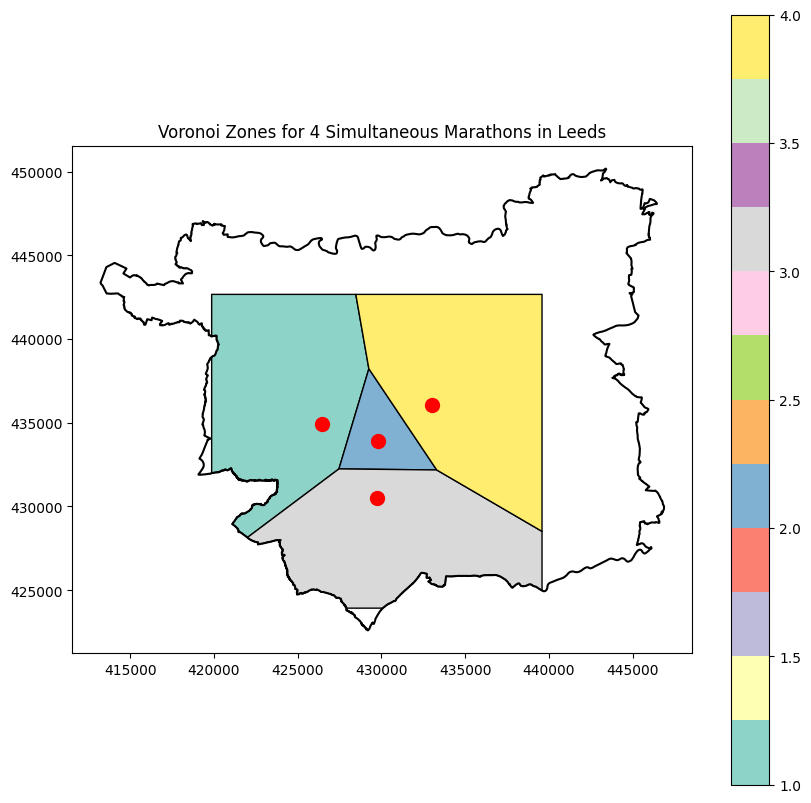

In [66]:
fig, ax = plt.subplots(figsize=(10,10))

voronoi_clipped.plot(
    column="marathon_id",
    cmap="Set3",
    edgecolor="black",
    legend=True,
    ax=ax
)

leeds.boundary.plot(ax=ax, color="black")

points.plot(ax=ax, color="red", markersize=100)

plt.title("Voronoi Zones for 4 Simultaneous Marathons in Leeds")

plt.show()